# Exploratory Data Analysis - Used Car Price Prediction

## Цель: Исследование данных для понимания факторов, влияющих на цену подержанных автомобилей.

### Используемые данные:
- `used_car_price_prediction_1M.csv` - полный датасет (~1M строк)

### Основные вопросы:
1. Как распределена целевая переменная (Price)?
2. Какие факторы сильнее всего влияют на цену?
3. Какие есть аномалии и пропуски?
4. Какие корреляции существуют между признаками?

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Pandas: 2.2.3
NumPy: 1.26.4


## 1. Загрузка данных

In [ ]:
# Путь к данным
DATA_PATH = os.path.join(os.getcwd(), '..', 'data', 'used_car_price_prediction_1M.csv')
# Проверка существования файла
if os.path.exists(DATA_PATH):
    print(f'Файл найден: {DATA_PATH}')
    # Загружаем часть данных для быстрого EDA (100K строк)
    df = pd.read_csv(DATA_PATH, nrows=100000)
else:
    print('Файл не найден')
    df = pd.DataFrame({
        'Price': [100000, 200000, 150000, 300000, 250000],
        'Year': [2015, 2018, 2016, 2020, 2019],
        'Kms_Driven': [50000, 30000, 45000, 20000, 35000]
    })

Файл найден: c:\Users\timam\Desktop\project\notebooks\..\data\used_car_price_prediction_1M.csv


## 2. Общая информация о данных

In [ ]:
print('=== Форма данных ===')
print(f'Строк: {df.shape[0]}')
print(f'Столбцов: {df.shape[1]}')

print('\n=== Первые 5 строк ===')
display(df.head())

=== Форма данных ===
Строк: 100000
Столбцов: 20

=== Первые 5 строк ===


,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05


In [ ]:
print('=== Информация о типах данных ===')
df.info()

=== Информация о типах данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Brand             100000 non-null  object 
 1   Model             100000 non-null  object 
 2   Year              100000 non-null  int64  
 3   Mileage_kmpl      91962 non-null   float64
 4   Engine_CC         91892 non-null   float64
 5   Horsepower        92069 non-null   float64
 6   Fuel_Type         92301 non-null   object 
 7   Transmission      91911 non-null   object 
 8   Owner_Type        100000 non-null  object 
 9   Color             91845 non-null   object 
 10  City              92096 non-null   object 
 11  Kms_Driven        100000 non-null  int64  
 12  Insurance_Valid   100000 non-null  int64  
 13  Service_History   100000 non-null  int64  
 14  Accidents         100000 non-null  int64  
 15  Tax_Paid          100000 non-null  

In [ ]:
print('=== Статистическое описание ===')
display(df.describe())

=== Статистическое описание ===


,Year,Mileage_kmpl,Engine_CC,Horsepower,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
count,100000.000000,91962.000000,91892.000000,92069.000000,1.000000e+05,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2012.000190,18.000400,1504.558347,120.331309,2.020223e+05,0.851540,0.75228,0.299000,0.900670,4.251210,5.161190,12.999810,1.008677e+06
std,7.216345,3.994542,386.402643,36.771806,1.728710e+05,0.355557,0.43169,0.544153,0.299106,0.698175,0.919411,7.216345,1.112999e+06
min,2000.000000,5.000000,800.000000,-18.509982,5.009000e+03,0.000000,0.00000,0.000000,0.000000,2.000000,2.000000,1.000000,5.000000e+04
25%,2006.000000,15.325199,1228.480287,94.694468,8.424000e+04,1.000000,1.00000,0.000000,1.000000,4.000000,5.000000,7.000000,3.435097e+05
50%,2012.000000,17.995570,1497.283084,119.733671,1.659265e+05,1.000000,1.00000,0.000000,1.000000,4.000000,5.000000,13.000000,7.594900e+05
75%,2018.000000,20.680489,1767.477755,145.139508,2.859370e+05,1.000000,1.00000,1.000000,1.000000,5.000000,5.000000,19.000000,1.291892e+06
max,2024.000000,34.760248,3245.326040,286.878228,4.344375e+06,1.000000,1.00000,5.000000,1.000000,5.000000,7.000000,25.000000,3.348553e+07


## 3. Анализ пропусков

In [ ]:
# Пропуски по столбцам
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Процент', ascending=False)

if len(missing_df) > 0:
    print('Пропущенные значения')
    display(missing_df)
else:
    print('Пропуски отсутствуют!')

Пропущенные значения


,Пропуски,Процент
Color,8155,8.155
Engine_CC,8108,8.108
Transmission,8089,8.089
Mileage_kmpl,8038,8.038
Horsepower,7931,7.931
City,7904,7.904
Fuel_Type,7699,7.699


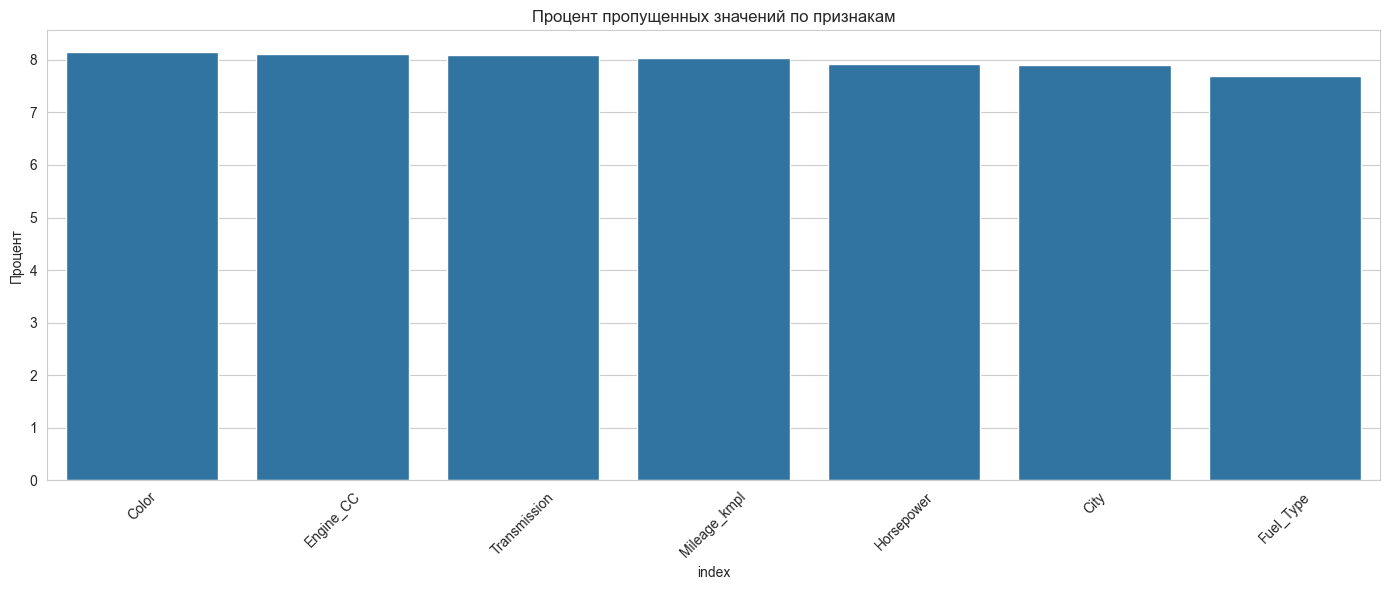

In [ ]:
# Визуализация пропусков
plt.figure(figsize=(14, 6))
if len(missing_df) > 0:
    sns.barplot(data=missing_df.reset_index(), x='index', y='Процент')
    plt.xticks(rotation=45)
    plt.title('Процент пропущенных значений по признакам')
    plt.tight_layout()
    plt.show()

## 4. Анализ целевой переменной (Price)

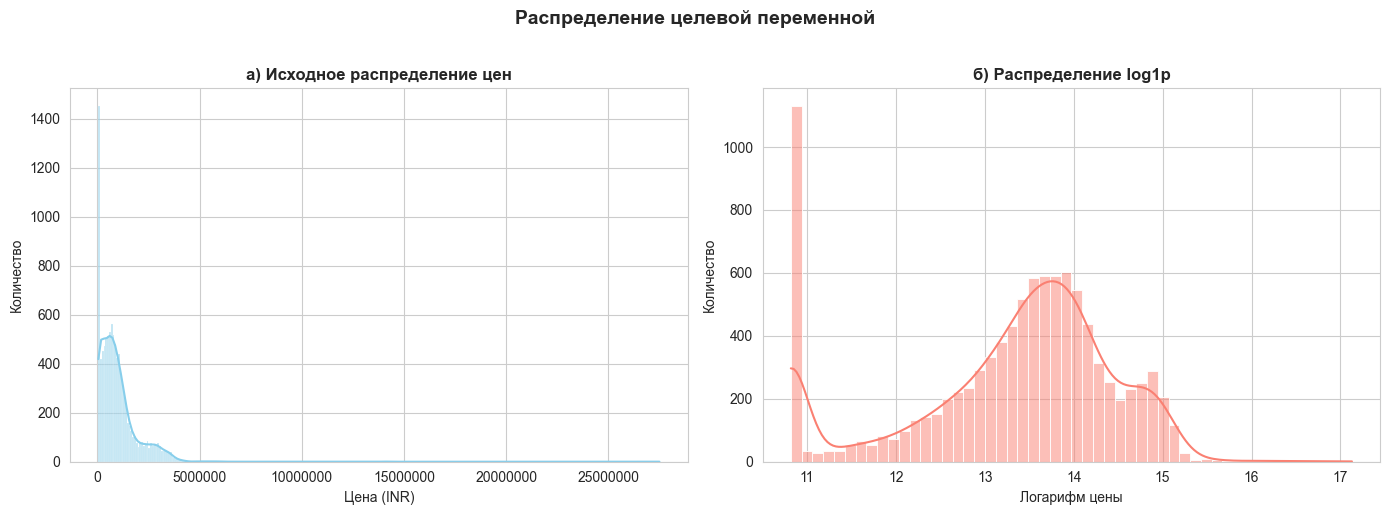


Статистика цен:
  Среднее: 1,008,272 INR
  Медиана: 763,236 INR
  Минимум: 50,000 INR
  Максимум: 27,493,880 INR
  Стандартное отклонение: 1,127,851


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Price', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('а) Исходное распределение цен', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Цена (INR)')
axes[0].set_ylabel('Количество')
axes[0].ticklabel_format(style='plain', axis='x')

df['log_Price'] = np.log1p(df['Price'])
sns.histplot(data=df, x='log_Price', kde=True, ax=axes[1], color='salmon')
axes[1].set_title('б) Распределение log1p', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Логарифм цены')
axes[1].set_ylabel('Количество')

plt.suptitle('Распределение целевой переменной', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика цен:")
print(f"  Среднее: {df['Price'].mean():,.0f} INR")
print(f"  Медиана: {df['Price'].median():,.0f} INR")
print(f"  Минимум: {df['Price'].min():,.0f} INR")
print(f"  Максимум: {df['Price'].max():,.0f} INR")
print(f"  Стандартное отклонение: {df['Price'].std():,.0f}")

## 5. Анализ ключевых признаков

In [ ]:
# Доступные числовые столбцы
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Числовые признаки:', num_cols)

Числовые признаки: ['Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower', 'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents', 'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price']


In [ ]:
# Доступные категориальные столбцы
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Категориальные признаки:', cat_cols)

Категориальные признаки: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City']


### 5.1 Год выпуска и цена

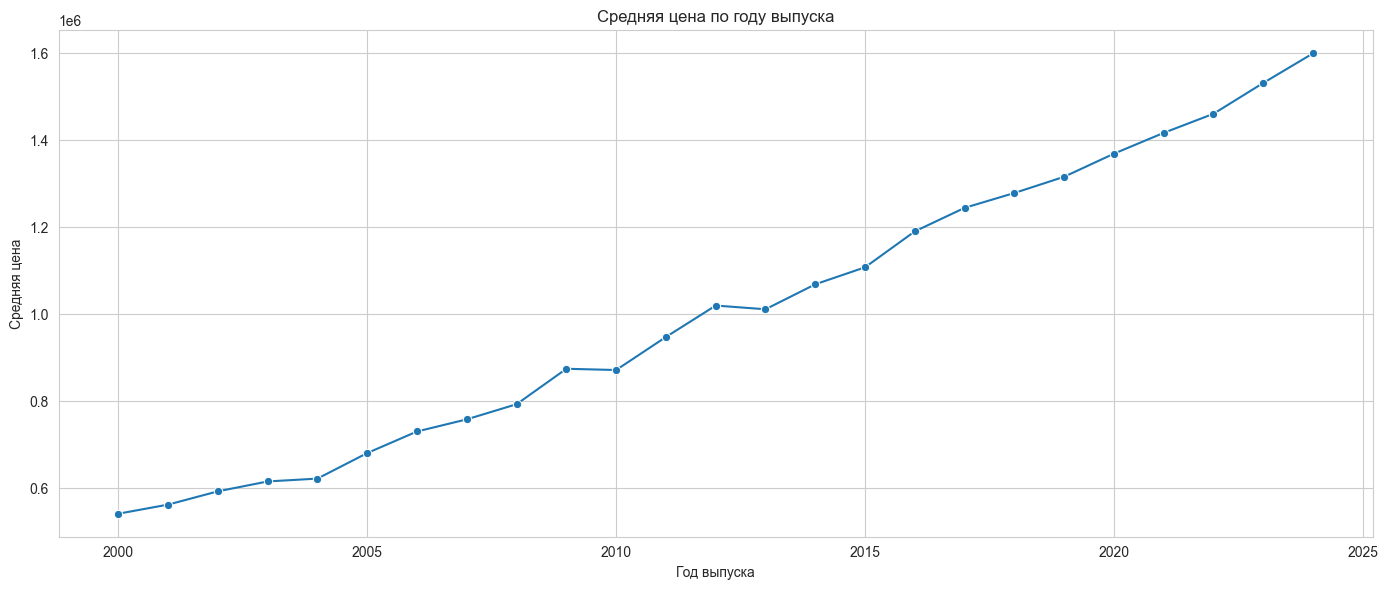

In [ ]:
if 'Year' in df.columns and 'Price' in df.columns:
    # Вычисляем возраст автомобиля
    df['Vehicle_Age'] = 2024 - df['Year']

    avg_price_by_year = df.groupby('Year')['Price'].agg(['mean', 'median', 'count']).reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=avg_price_by_year, x='Year', y='mean', marker='o')
    plt.title('Средняя цена по году выпуска')
    plt.xlabel('Год выпуска')
    plt.ylabel('Средняя цена')
    plt.tight_layout()
    plt.show()

### 5.2 Пробег и цена

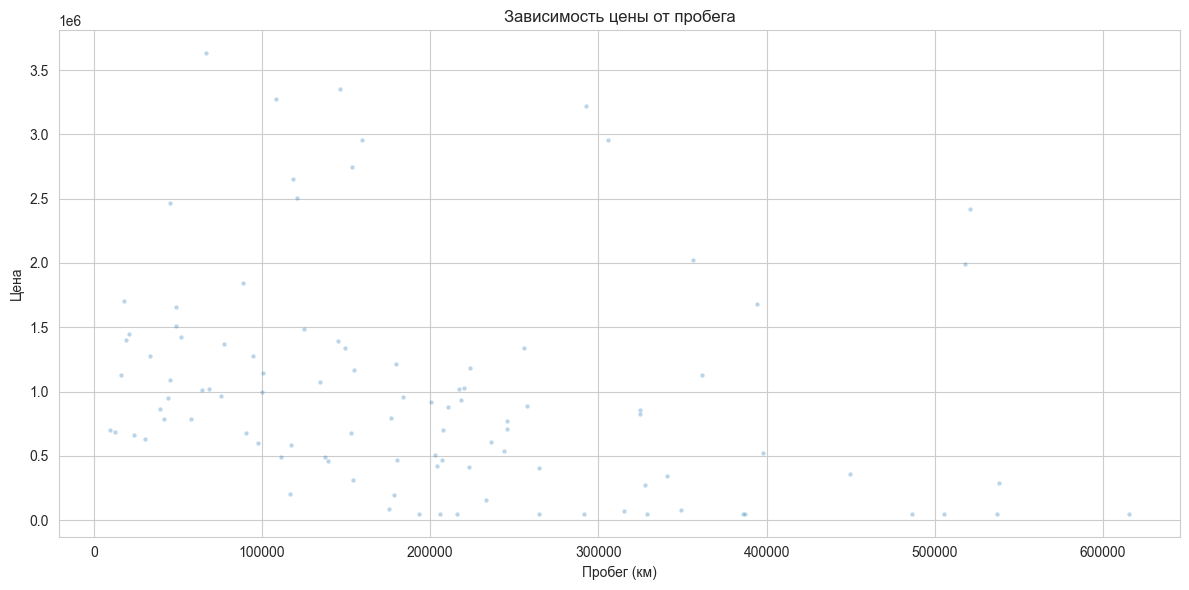

In [ ]:
if 'Kms_Driven' in df.columns and 'Price' in df.columns:
    plt.figure(figsize=(12, 6))

    # Случайная выборка для визуализации
    sample = df.sample(min(100, len(df)), random_state=42)

    sns.scatterplot(data=sample, x='Kms_Driven', y='Price', alpha=0.3, s=10)
    plt.title('Зависимость цены от пробега')
    plt.xlabel('Пробег (км)')
    plt.ylabel('Цена')
    plt.tight_layout()
    plt.show()

### 5.3 Мощность двигателя и цена

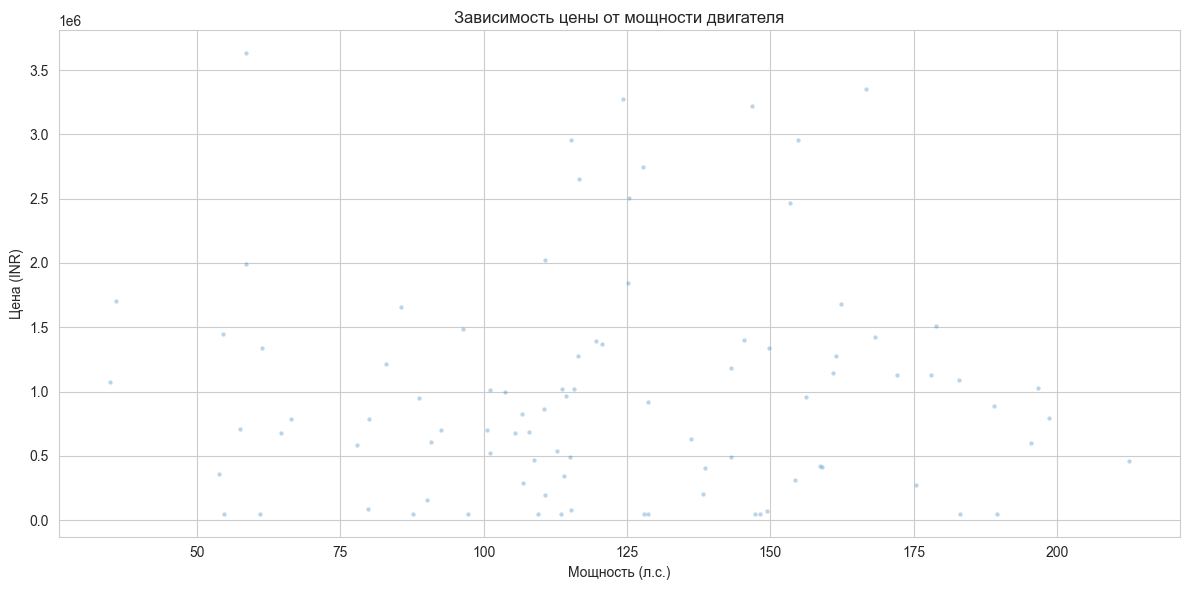

In [ ]:
if 'Horsepower' in df.columns and 'Price' in df.columns:
    plt.figure(figsize=(12, 6))

    sample = df.sample(min(100, len(df)), random_state=42)

    sns.scatterplot(data=sample, x='Horsepower', y='Price', alpha=0.3, s=10)
    plt.title('Зависимость цены от мощности двигателя')
    plt.xlabel('Мощность (л.с.)')
    plt.ylabel('Цена (INR)')
    plt.tight_layout()
    plt.show()

### 5.4 Влияние марки автомобиля

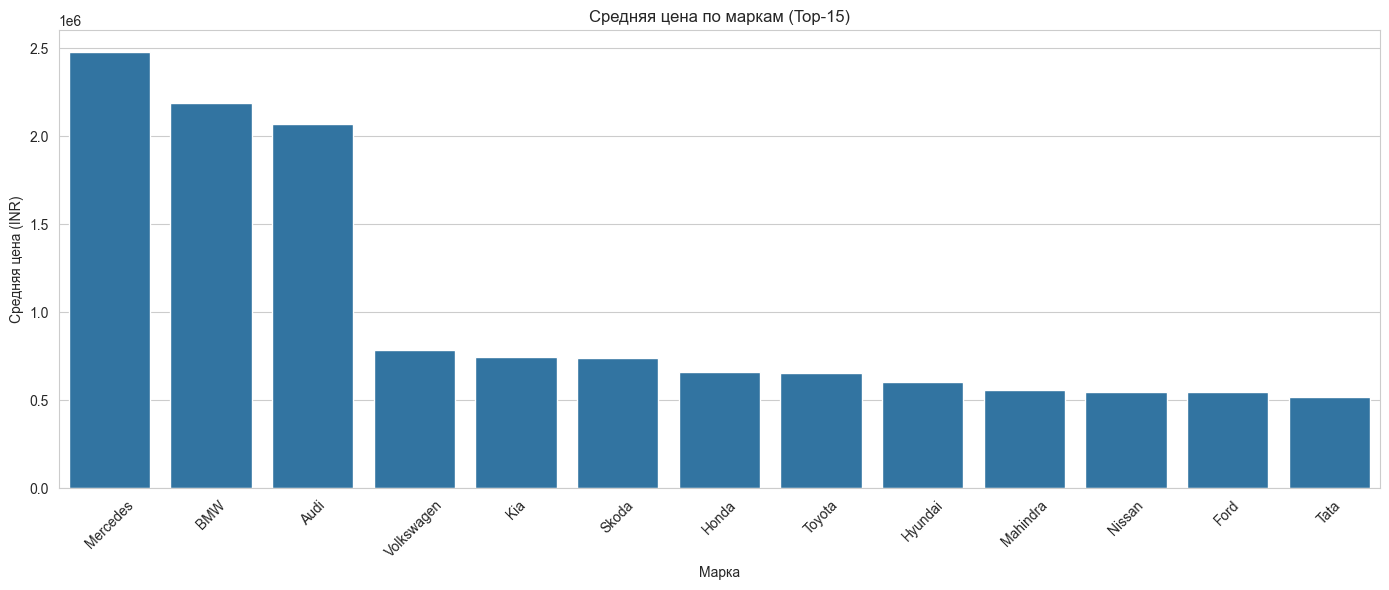

In [ ]:
df['Brand'] = df['Brand'].str.strip()
if 'Brand' in df.columns and 'Price' in df.columns:
    brand_stats = df.groupby('Brand')['Price'].agg(['mean', 'median', 'count']).reset_index()
    brand_stats = brand_stats.sort_values('mean', ascending=False).head(15)

    plt.figure(figsize=(14, 6))
    sns.barplot(data=brand_stats, x='Brand', y='mean')
    plt.title('Средняя цена по маркам (Top-15)')
    plt.xlabel('Марка')
    plt.ylabel('Средняя цена (INR)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
print("Уникальные бренды в данных:")
print(df['Brand'].unique())
print(f"\nВсего уникальных названий: {df['Brand'].nunique()}")

Уникальные бренды в данных:
['Toyota' 'Hyundai' 'Mahindra' 'BMW' 'Honda' 'Volkswagen' 'Audi'
 'Mercedes' 'Kia' 'Ford' 'Nissan' 'Tata' 'Skoda']

Всего уникальных названий: 13


### 5.5 Тип топлива и цена

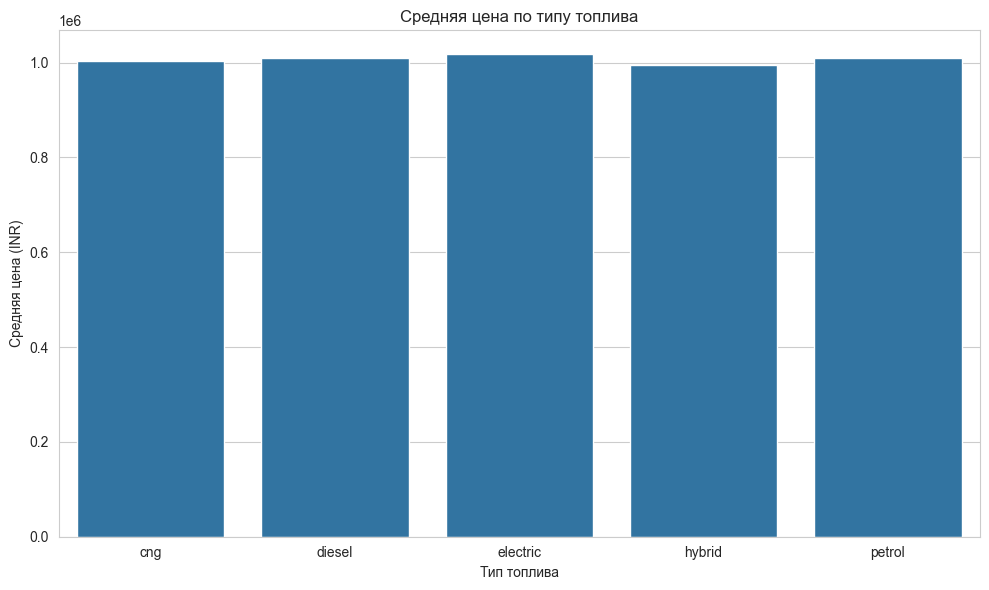

In [ ]:
df['Fuel_Type'] = df['Fuel_Type'].str.strip().str.lower()
df['Fuel_Type'] = df['Fuel_Type'].replace({'electrik': 'electric', 'hybridd': 'hybrid', 'petrol': 'petrol'})
if 'Fuel_Type' in df.columns and 'Price' in df.columns:
    fuel_stats = df.groupby('Fuel_Type')['Price'].agg(['mean', 'count']).reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fuel_stats, x='Fuel_Type', y='mean')
    plt.title('Средняя цена по типу топлива')
    plt.xlabel('Тип топлива')
    plt.ylabel('Средняя цена (INR)')
    plt.tight_layout()
    plt.show()

## 6. Корреляционный анализ

In [ ]:
if 'Price' in df.columns:
    # Выбираем числовые признаки
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if len(numeric_df.columns) > 1:
        corr_matrix = numeric_df.corr()

        # Корреляция с ценой
        price_corr = corr_matrix['Price'].drop('Price').sort_values(ascending=False)

        print('=== Корреляция с целевой переменной (Price) ===')
        display(price_corr)

=== Корреляция с целевой переменной (Price) ===


Year                0.290050
Horsepower          0.043355
Engine_CC           0.036267
Service_History     0.018131
Mileage_kmpl        0.002258
Insurance_Valid     0.001117
Tax_Paid           -0.002133
Number_of_Doors    -0.002208
Seats              -0.002427
Accidents          -0.006572
Kms_Driven         -0.070519
Registration_Age   -0.290050
Vehicle_Age        -0.290050
Name: Price, dtype: float64

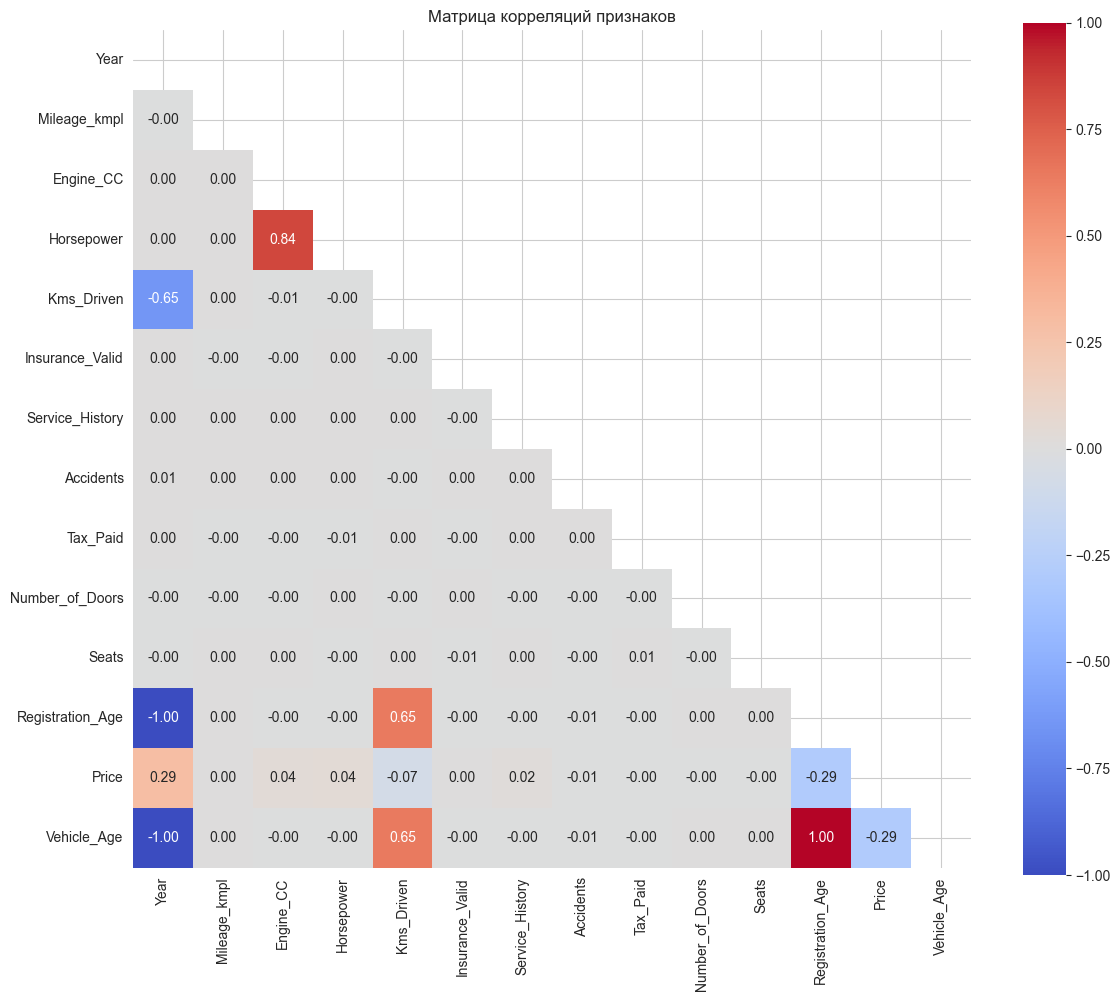

In [ ]:
# Матрица корреляций
if 'Price' in df.columns:
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if len(numeric_df.columns) > 1:
        corr_matrix = numeric_df.corr()

        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, vmin=-1, vmax=1)
        plt.title('Матрица корреляций признаков')
        plt.tight_layout()
        plt.show()

## 7. Анализ по городам

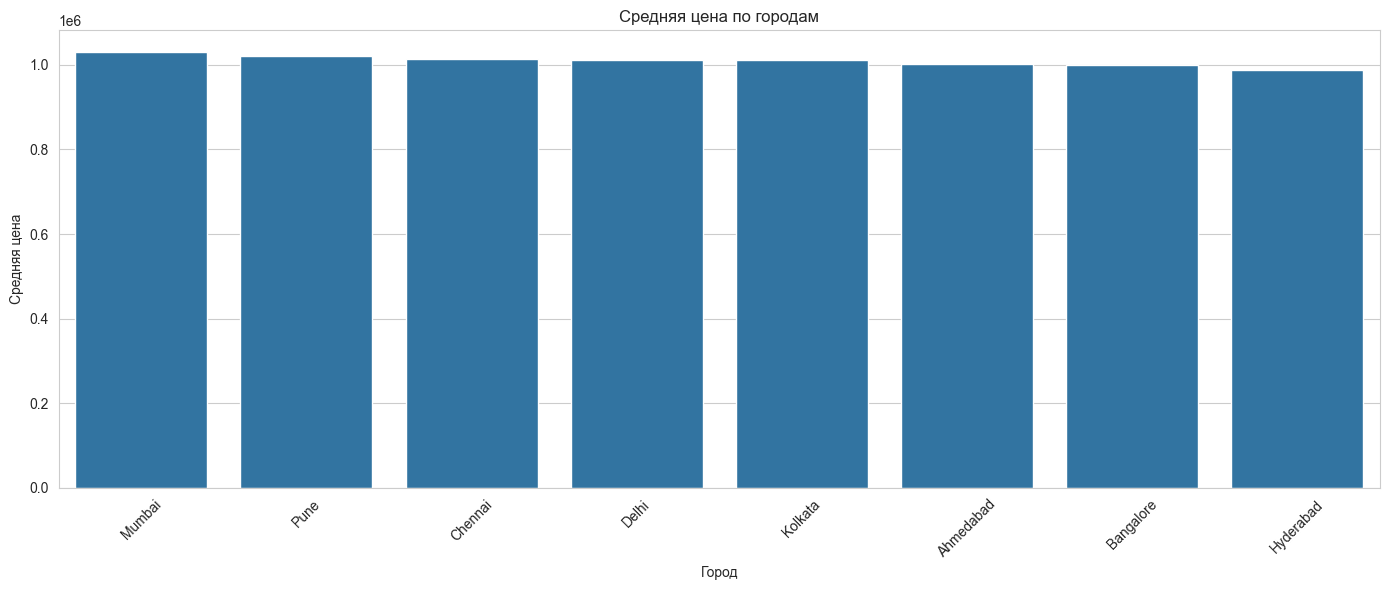

In [ ]:
if 'City' in df.columns and 'Price' in df.columns:
    city_stats = df.groupby('City')['Price'].agg(['mean', 'median', 'count']).reset_index()
    city_stats = city_stats.sort_values('mean', ascending=False).head(10)

    plt.figure(figsize=(14, 6))
    sns.barplot(data=city_stats, x='City', y='mean')
    plt.title('Средняя цена по городам')
    plt.xlabel('Город')
    plt.ylabel('Средняя цена')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Выводы

### Ключевые наблюдения:

1. **Распределение цены**: Сильно правостороннее, требует логарифмирования
2. **Год выпуска**: Сильный фактор - новые автомобили значительно дороже
3. **Пробег**: Больше пробег = ниже цена
4. **Мощность двигателя**: Прямая корреляция с ценой
5. **Марка автомобиля**: Значительное влияние на цену
6. **Тип топлива**: Дизельные автомобили обычно дороже бензиновых
7. **Город продажи**: Влияет на цену из-за спроса/предложения

